# SVM vs QSVM

Environment setup and package verification.

In [1]:
%pip install -q -U scikit-learn qiskit qiskit-machine-learning matplotlib 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sklearn
import qiskit
import qiskit_machine_learning
import matplotlib

print('scikit-learn:', sklearn.__version__)
print('qiskit:', qiskit.__version__)
print('qiskit-machine-learning:', qiskit_machine_learning.__version__)
print('matplotlib:', matplotlib.__version__)
print('Setup complete.')

scikit-learn: 1.9.0
qiskit: 2.5.0
qiskit-machine-learning: 0.9.0
matplotlib: 3.11.0
Setup complete.


## Breast Cancer Wisconsin: Dataset Preparation

This section loads, standardizes, and prepares the data with PCA for SVM and QSVM models.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
# Load the dataset directly and build X and y using the original feature names
breast_cancer = load_breast_cancer()
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target, name='target')

class_names = breast_cancer.target_names
# X.head()
# class_names
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [5]:
# Initial dataset information
print(f'Data dimensions: {X.shape}')
print(f'Number of features: {X.shape[1]}')
print(f'Class names: {list(class_names)}')
print('\nSamples per class:')
print(y.map(dict(enumerate(class_names))).value_counts())
print('\nFirst five rows:')
display(X.head())
print('\nMissing values per column:')
# display(X.isna().sum())
print(f'Total missing values: {X.isna().sum().sum()}')

Data dimensions: (569, 30)
Number of features: 30
Class names: [np.str_('malignant'), np.str_('benign')]

Samples per class:
target
benign       357
malignant    212
Name: count, dtype: int64

First five rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Missing values per column:
Total missing values: 0


In [6]:
# Stratified split: 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Fit the scaler only on training data to prevent data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training dimensions: {X_train.shape}')
print(f'Test dimensions: {X_test.shape}')

Training dimensions: (455, 30)
Test dimensions: (114, 30)


In [7]:
# Two-component PCA: fit only on standardized training data
pca_2 = PCA(n_components=2)
X_train_pca_2 = pca_2.fit_transform(X_train_scaled)
X_test_pca_2 = pca_2.transform(X_test_scaled)

print(f'Training output dimensions (2 components): {X_train_pca_2.shape}')
print(f'Test output dimensions (2 components): {X_test_pca_2.shape}')
print(f'Explained Variance Ratio: {pca_2.explained_variance_ratio_}')
print(f'Total explained variance: {pca_2.explained_variance_ratio_.sum():.4f}')

Training output dimensions (2 components): (455, 2)
Test output dimensions (2 components): (114, 2)
Explained Variance Ratio: [0.44413492 0.18944618]
Total explained variance: 0.6336


In [8]:
# Four-component PCA: fit only on standardized training data
pca_4 = PCA(n_components=4)
X_train_pca_4 = pca_4.fit_transform(X_train_scaled)
X_test_pca_4 = pca_4.transform(X_test_scaled)

print(f'Training output dimensions (4 components): {X_train_pca_4.shape}')
print(f'Test output dimensions (4 components): {X_test_pca_4.shape}')
print(f'Explained Variance Ratio: {pca_4.explained_variance_ratio_}')
print(f'Total explained variance: {pca_4.explained_variance_ratio_.sum():.4f}')

Training output dimensions (4 components): (455, 4)
Test output dimensions (4 components): (114, 4)
Explained Variance Ratio: [0.44413492 0.18944618 0.09543356 0.06724689]
Total explained variance: 0.7963


In [9]:
# Convert PCA outputs to DataFrames with component names
pca_2_columns = ['PC1', 'PC2']
pca_4_columns = ['PC1', 'PC2', 'PC3', 'PC4']

X_train_pca_2_df = pd.DataFrame(X_train_pca_2, columns=pca_2_columns, index=X_train.index)
X_test_pca_2_df = pd.DataFrame(X_test_pca_2, columns=pca_2_columns, index=X_test.index)
X_train_pca_4_df = pd.DataFrame(X_train_pca_4, columns=pca_4_columns, index=X_train.index)
X_test_pca_4_df = pd.DataFrame(X_test_pca_4, columns=pca_4_columns, index=X_test.index)

display(X_train_pca_2_df.head())
display(X_train_pca_4_df.head())

,PC1,PC2
546,-4.167251,0.255512
432,4.597260,-0.967634
174,-4.564327,-0.171496
221,-0.883693,0.438912
289,-2.951399,0.365633


,PC1,PC2,PC3,PC4
546,-4.167251,0.255512,-0.352313,-0.647903
432,4.597260,-0.967634,-0.560218,-0.884330
174,-4.564327,-0.171496,1.506432,-0.714315
221,-0.883693,0.438912,-1.449090,-1.957159
289,-2.951399,0.365633,1.181772,0.569040


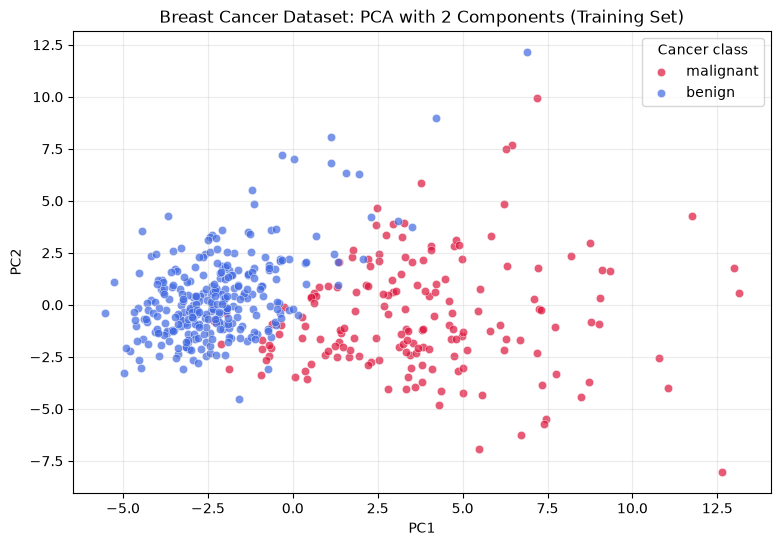

In [10]:
# Plot the first two PCA components for the training data
plt.figure(figsize=(9, 6))
colors = {'malignant': 'crimson', 'benign': 'royalblue'}
for class_id, class_name in enumerate(class_names):
    mask = y_train == class_id
    plt.scatter(
        X_train_pca_2[mask, 0], X_train_pca_2[mask, 1],
        label=class_name, color=colors[class_name], alpha=0.7, edgecolor='white', linewidth=0.4
    )

plt.title('Breast Cancer Dataset: PCA with 2 Components (Training Set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cancer class')
plt.grid(alpha=0.25)
plt.show()

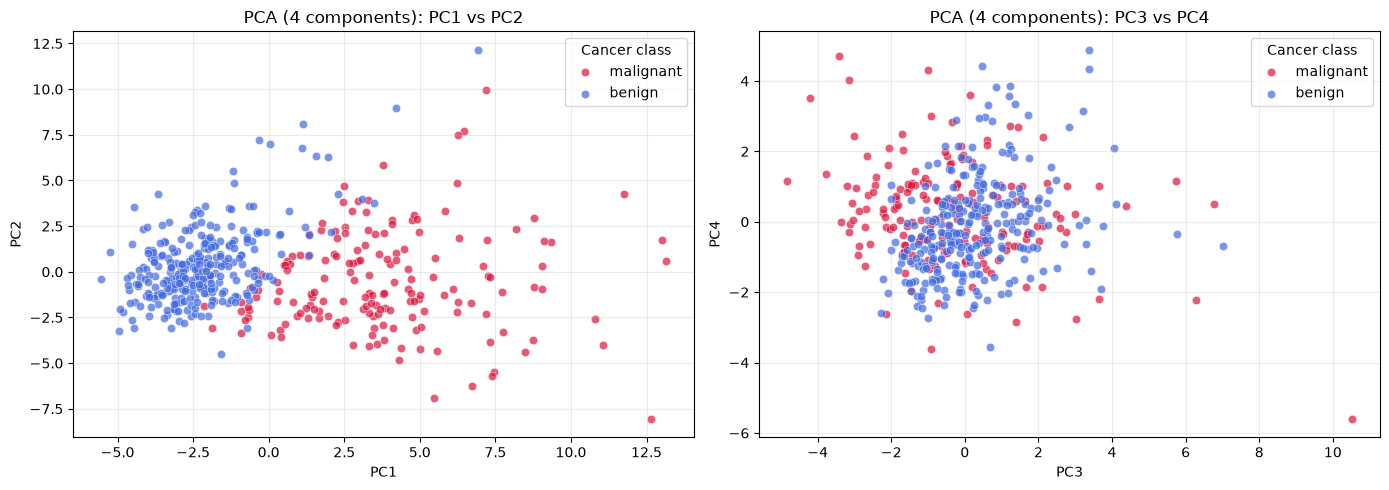

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'malignant': 'crimson', 'benign': 'royalblue'}

for class_id, class_name in enumerate(class_names):
    mask = y_train == class_id
    
    # PC1 vs PC2
    axes[0].scatter(
        X_train_pca_4[mask, 0], X_train_pca_4[mask, 1],
        label=class_name,
        color=colors[class_name],
        alpha=0.7,
        edgecolor='white',
        linewidth=0.4
    )
    
    # PC3 vs PC4
    axes[1].scatter(
        X_train_pca_4[mask, 2], X_train_pca_4[mask, 3],
        label=class_name,
        color=colors[class_name],
        alpha=0.7,
        edgecolor='white',
        linewidth=0.4
    )

axes[0].set_title('PCA (4 components): PC1 vs PC2')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.25)
axes[0].legend(title='Cancer class')

axes[1].set_title('PCA (4 components): PC3 vs PC4')
axes[1].set_xlabel('PC3')
axes[1].set_ylabel('PC4')
axes[1].grid(alpha=0.25)
axes[1].legend(title='Cancer class')

plt.tight_layout()
plt.show()

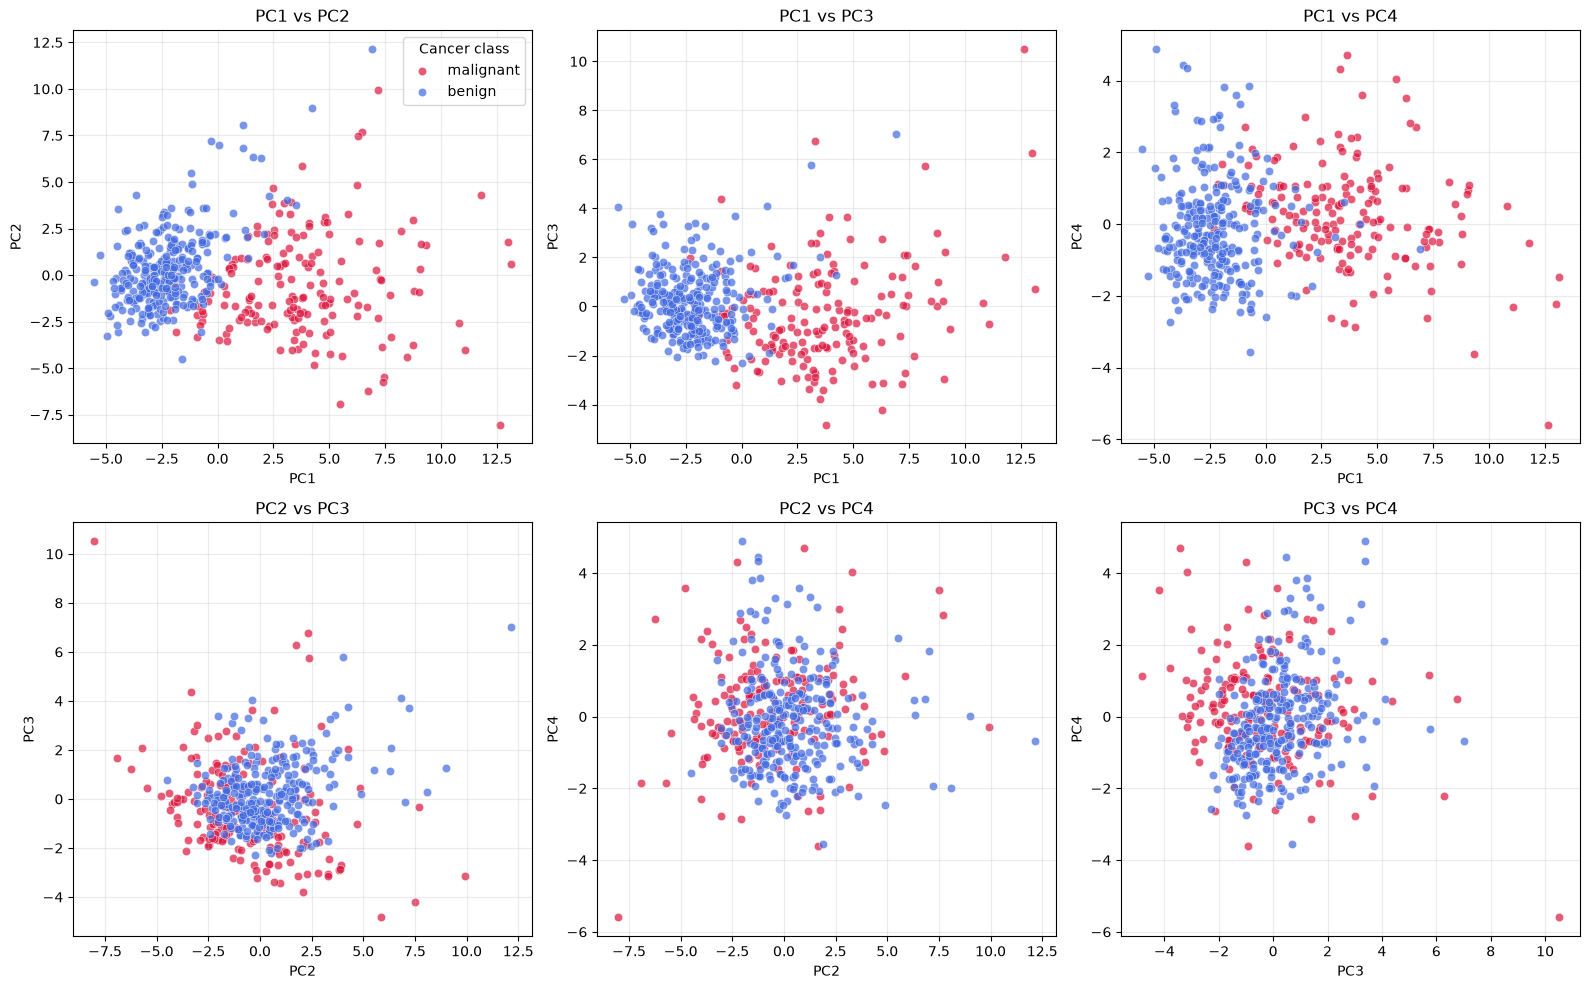

In [12]:
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

colors = {'malignant': 'crimson', 'benign': 'royalblue'}

for ax, (i, j) in zip(axes, pairs):
    for class_id, class_name in enumerate(class_names):
        mask = y_train == class_id
        ax.scatter(
            X_train_pca_4[mask, i], X_train_pca_4[mask, j],
            label=class_name,
            color=colors[class_name],
            alpha=0.7,
            edgecolor='white',
            linewidth=0.4
        )
    ax.set_xlabel(f'PC{i+1}')
    ax.set_ylabel(f'PC{j+1}')
    ax.set_title(f'PC{i+1} vs PC{j+1}')
    ax.grid(alpha=0.25)

axes[0].legend(title='Cancer class')
plt.tight_layout()
plt.show()

### Key Notes

- **Standardization before PCA is essential** because PCA is sensitive to feature scales; larger-range features could otherwise dominate the components.
- **PCA reduces the number of features**, which can reduce the number of qubits required to encode features for QSVM and make quantum circuit execution more practical.
- **The scaler and PCA are fit only on training data** so no test-set information enters training, keeping evaluation valid and free of data leakage.

## 2. Classical SVM Benchmark

A standard radial-basis-function (RBF) SVM is trained on the standardized training set. Its test accuracy is the main classical benchmark for the later QSVM comparison.

In [13]:
from time import perf_counter

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train the classical benchmark on all standardized features.
classical_svm = SVC(kernel='rbf', C=1.0, gamma='scale')

start_time = perf_counter()
classical_svm.fit(X_train_scaled, y_train)
classical_svm_training_time = perf_counter() - start_time

y_pred_classical = classical_svm.predict(X_test_scaled)
classical_svm_accuracy = accuracy_score(y_test, y_pred_classical)

print(f'Classical SVM test accuracy: {classical_svm_accuracy:.4f} '      f'({classical_svm_accuracy * 100:.2f}%)')
print(f'Training time: {classical_svm_training_time:.6f} seconds')
print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred_classical))
print('\nClassification report:')
print(classification_report(y_test, y_pred_classical, target_names=class_names, digits=4))

Classical SVM test accuracy: 0.9825 (98.25%)
Training time: 0.003485 seconds

Confusion matrix:
[[41  1]
 [ 1 71]]

Classification report:
              precision    recall  f1-score   support

   malignant     0.9762    0.9762    0.9762        42
      benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



### PCA-matched classical baselines

Because a QSVM will use a reduced number of features, the same SVM configuration is also evaluated on the 2- and 4-component PCA representations. These scores enable a fair comparison at the same input dimensionality.

In [14]:
classical_svm_results = [{
    'model': 'Classical SVM',
    'features': 'All standardized features',
    'n_features': X_train_scaled.shape[1],
    'accuracy': classical_svm_accuracy,
    'training_time_seconds': classical_svm_training_time,
}]

pca_datasets = {
    'PCA (2 components)': (X_train_pca_2, X_test_pca_2),
    'PCA (4 components)': (X_train_pca_4, X_test_pca_4),
}

classical_svm_pca_models = {}
for feature_name, (X_train_variant, X_test_variant) in pca_datasets.items():
    model = SVC(kernel='rbf', C=1.0, gamma='scale')
    start_time = perf_counter()
    model.fit(X_train_variant, y_train)
    training_time = perf_counter() - start_time
    accuracy = accuracy_score(y_test, model.predict(X_test_variant))

    classical_svm_pca_models[feature_name] = model
    classical_svm_results.append({
        'model': 'Classical SVM',
        'features': feature_name,
        'n_features': X_train_variant.shape[1],
        'accuracy': accuracy,
        'training_time_seconds': training_time,
    })

classical_svm_benchmark = pd.DataFrame(classical_svm_results)
classical_svm_benchmark['accuracy_percent'] = (
    100 * classical_svm_benchmark['accuracy']
).round(2)
classical_svm_benchmark

,model,features,n_features,accuracy,training_time_seconds,accuracy_percent
0,Classical SVM,All standardized features,30,0.982456,0.003485,98.25
1,Classical SVM,PCA (2 components),2,0.947368,0.001811,94.74
2,Classical SVM,PCA (4 components),4,0.964912,0.001022,96.49
